# SC-FC Coupling Cognitive State Classification using Multi-Layer Perceptron (MLP)

This notebook trains a custom Multi-Layer Perceptron (MLP) model to predict whether a subject is **NORMCOG** (Normal Cognition) or **DEMENTED** using brain SC-FC coupling vectors data.

We use a stratified 3-way dataset split (70% Training, 15% Validation, and 15% Testing) to guarantee unbiased evaluation and prevent data leakage.

## 1. Import Libraries

We begin by importing the required deep learning, data processing, and plotting packages.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import time
import pandas as pd
import seaborn as sns
import itertools
!pip install torchinfo
from torchinfo import summary
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, f1_score

## 2. Configure Device

Configure GPU acceleration (`cuda`) if it is available; otherwise, fall back to CPU.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## 3. Load and Preprocess Data

We load the SC-FC coupling features CSV file. Then, we encode the target variable (`NORMCOG` -> 0, `DEMENTED` -> 1) as class indices.

In [3]:
# Load the dataset using a relative path 
df = pd.read_csv("/home/jovyan/Desktop/PBL_Neuro/DL/MLP_sc_fc_coupling/Myelin_FC_coupling_vectors.csv")
df_metadata = pd.read_csv("/home/jovyan/Desktop/PBL_Neuro/DL/MLP_sc_fc_coupling/OASIS3_metadata_final.csv")

# Numerical dummy variable encoding: NORMCOG -> 0, DEMENTED -> 1
df['target'] = df['group'].map({'NORMCOG': 0, 'DEMENTED': 1})
df = df.dropna(subset=['target'])

# Define features dynamically by name (excluding Subject_ID, group, target, and Age)
id_col = 'Subject_ID'
target_col = 'target'
coupling_cols = [col for col in df.columns if col not in [id_col, 'group', target_col, 'Age']]

# Define class names for plotting/reporting
class_names = ['NORMCOG', 'DEMENTED']

print(f"Number of SC-FC coupling vector features: {len(coupling_cols)}")
print(f"Class counts:\n{df['group'].value_counts()}")

# Añadir la columna Age desde el metadata usando el subject ID
df = df.merge(
    df_metadata[['Subject_ID', 'Age']],
    left_on='Subject_ID',
    right_on='Subject_ID',
    how='left'
)
df = df.merge(
    df_metadata[['Subject_ID', 'Gender']],
    left_on='Subject_ID',
    right_on='Subject_ID',
    how='left'
)

Number of SC-FC coupling vector features: 7
Class counts:
group
NORMCOG     684
DEMENTED    399
Name: count, dtype: int64


In [4]:
df.head()

,Subject_ID,group,fc_myelin_coupling_Vis,fc_myelin_coupling_SomMot,fc_myelin_coupling_DorsAttn,fc_myelin_coupling_SalVentAttn,fc_myelin_coupling_Limbic,fc_myelin_coupling_Cont,fc_myelin_coupling_Default,target,Age,Gender
0,OAS30001,NORMCOG,0.173979,-0.022206,-0.000834,-0.026789,-0.006844,0.039038,0.011638,0,65.54,2
1,OAS30002,NORMCOG,0.054960,-0.109930,-0.049039,-0.121121,-0.037282,-0.141439,-0.047350,0,69.04,1
2,OAS30003,NORMCOG,0.192220,-0.037714,-0.062666,-0.049135,0.047912,0.006713,0.002891,0,60.34,2
3,OAS30004,NORMCOG,0.125525,0.172956,0.102253,0.024435,0.005592,0.067687,0.022383,0,58.14,2
4,OAS30005,NORMCOG,0.071141,0.169766,0.079471,0.077136,0.009362,0.115633,0.103226,0,49.65,2


## 4. Stratified Three-Way Dataset Splitting

We split the dataset into 60% Training, 20% Validation, and 20% Testing. Features are scaled using a standard scaler fitted only on the training set to prevent data leakage.

In [5]:
# Stratify by label + age bin + gender to ensure balanced distributions:
df["age_bin"] = (df["Age"] >= 75).astype(int)
df["strat"]   = (
    df["target"].astype(str) + "_" +
    df["age_bin"].astype(str) + "_" +
    df["Gender"].astype(str)   # 1 = male, 2 = female
)

print("Stratum distribution:\n", df["strat"].value_counts())

test_val_df, train_df = train_test_split(
    df, test_size=0.6, stratify=df["strat"], random_state=34
)
test_df, val_df = train_test_split(
    test_val_df, test_size=0.5, stratify=test_val_df["strat"], random_state=34
)

print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n── {name} ──")
    print(split["target"].value_counts(normalize=True).rename({0: "Normal", 1: "Demented"}))
    print(f"Age mean : {split['Age'].mean():.1f}  std: {split['Age'].std():.1f}")
    print(f"Gender   : {split['Gender'].value_counts(normalize=True).rename({1: 'Male', 2: 'Female'}).to_dict()}")

print(f"Split sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Scale SC-FC coupling vectors based on training data statistics
coupling_scaler = StandardScaler()
X_train_coupling = coupling_scaler.fit_transform(train_df[coupling_cols])
X_val_coupling = coupling_scaler.transform(val_df[coupling_cols])
X_test_coupling = coupling_scaler.transform(test_df[coupling_cols])

y_train = train_df[target_col].values
y_val = val_df[target_col].values
y_test = test_df[target_col].values

Stratum distribution:
 strat
0_0_2    341
0_0_1    235
1_1_1    118
1_1_2    108
1_0_1     92
1_0_2     81
0_1_2     63
0_1_1     45
Name: count, dtype: int64

Train: 650  |  Val: 217  |  Test: 216
Total: 1083

── Train ──
target
Normal      0.632308
Demented    0.367692
Name: proportion, dtype: float64
Age mean : 70.3  std: 9.5
Gender   : {'Female': 0.5476923076923077, 'Male': 0.4523076923076923}

── Val ──
target
Normal      0.626728
Demented    0.373272
Name: proportion, dtype: float64
Age mean : 70.4  std: 8.5
Gender   : {'Female': 0.543778801843318, 'Male': 0.45622119815668205}

── Test ──
target
Normal      0.634259
Demented    0.365741
Name: proportion, dtype: float64
Age mean : 71.2  std: 9.1
Gender   : {'Female': 0.5509259259259259, 'Male': 0.44907407407407407}
Split sizes - Train: 650 | Val: 217 | Test: 216


## 5. PyTorch Datasets and Dataloaders

We create a custom PyTorch Dataset class to manage batch delivery. We reshape the SC-FC coupling vector to `(1, num_features)` to represent a single input channel.

In [6]:
class CouplingDataset(Dataset):
    def __init__(self, myelin_features, targets):
        self.myelin = torch.tensor(myelin_features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.long)
        
    def __len__(self):
        return len(self.targets)
        
    def __getitem__(self, idx):
        # Reshape to (1, num_features) to represent 1 channel for 1D convolutions
        myelin_tensor = self.myelin[idx].unsqueeze(0)
        return myelin_tensor, self.targets[idx]

batch_size = 16
train_dataset = CouplingDataset(X_train_coupling, y_train)
val_dataset = CouplingDataset(X_val_coupling, y_val)
test_dataset = CouplingDataset(X_test_coupling, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")

Number of training batches: 41


## 6. Model Architecture

We design our Multi-Layer Perceptron (MLP) Neural Network model, which flattens the input vector and passes it through fully connected layers with Batch Normalization, ReLUs, and Dropout.

In [7]:
class CouplingMLP(nn.Module):
    def __init__(self, input_dim, num_classes=2, dropout_rate=0.3):
        super(CouplingMLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # Reshape / Flatten if input tensor has 3 dimensions (batch_size, 1, input_dim)
        if x.dim() > 2:
            x = torch.flatten(x, 1)
        return self.fc(x)

model = CouplingMLP(input_dim=len(coupling_cols)).to(device)
summary(model, input_size=(32, 1, len(coupling_cols)))

Layer (type:depth-idx)                   Output Shape              Param #
CouplingMLP                              [32, 2]                   --
├─Sequential: 1-1                        [32, 2]                   --
│    └─Linear: 2-1                       [32, 256]                 2,048
│    └─BatchNorm1d: 2-2                  [32, 256]                 512
│    └─ReLU: 2-3                         [32, 256]                 --
│    └─Dropout: 2-4                      [32, 256]                 --
│    └─Linear: 2-5                       [32, 128]                 32,896
│    └─BatchNorm1d: 2-6                  [32, 128]                 256
│    └─ReLU: 2-7                         [32, 128]                 --
│    └─Dropout: 2-8                      [32, 128]                 --
│    └─Linear: 2-9                       [32, 64]                  8,256
│    └─BatchNorm1d: 2-10                 [32, 64]                  128
│    └─ReLU: 2-11                        [32, 64]                  --
│ 

## 7. Model Training Setup

We write a training function with early stopping, saving the best weights whenever validation **F1-macro** improves.

In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=50, epoch_details=True):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = 0.0
    patience_counter = 0
    early_stop_patience = 10
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        train_preds, train_labels = [], []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
            
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_preds, val_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                val_preds.extend(predicted.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                
        epoch_train_loss = train_loss / len(train_loader)
        epoch_val_loss = val_loss / len(val_loader)
        epoch_train_acc = 100 * train_correct / train_total
        epoch_val_acc = 100 * val_correct / val_total
        epoch_train_f1 = f1_score(train_labels, train_preds, average='macro')
        epoch_val_f1 = f1_score(val_labels, val_preds, average='macro')
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        history['train_f1'].append(epoch_train_f1)
        history['val_f1'].append(epoch_val_f1)
        
        if epoch_details:
            print(f"Epoch {epoch+1}/{epochs}: Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2f}% F1: {epoch_train_f1:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.2f}% F1: {epoch_val_f1:.4f}")
            
        scheduler.step(epoch_val_loss)
        
        # Early stopping & model saving based on maximizing F1-macro score
        if epoch_val_f1 > best_val_f1:
            best_val_f1 = epoch_val_f1
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model_sc_fc.pth')
            if epoch_details:
                print(f"SAVED model so far) (Best Val F1: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                if epoch_details:
                    print("EARLY STOPPING...")
                break
                
    model.load_state_dict(torch.load('best_model_sc_fc.pth'))
    return history

## 8. Run Training

Train the model for 50 epochs using early stopping (maximizing validation F1-macro) and standard optimizer settings.

In [9]:
epochs = 50
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
criterion = nn.CrossEntropyLoss()

history = train_model(model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=device, epochs=epochs)

Epoch 1/50: Train Loss: 0.6253 Acc: 66.46% F1: 0.6333 | Val Loss: 0.5636 Acc: 72.35% F1: 0.6705
SAVED model so far) (Best Val F1: 0.6705)
Epoch 2/50: Train Loss: 0.5447 Acc: 72.46% F1: 0.6871 | Val Loss: 0.5541 Acc: 71.89% F1: 0.6796
SAVED model so far) (Best Val F1: 0.6796)
Epoch 3/50: Train Loss: 0.5508 Acc: 71.38% F1: 0.6737 | Val Loss: 0.5586 Acc: 72.35% F1: 0.6904
SAVED model so far) (Best Val F1: 0.6904)
Epoch 4/50: Train Loss: 0.5353 Acc: 73.23% F1: 0.7043 | Val Loss: 0.5572 Acc: 72.81% F1: 0.7004
SAVED model so far) (Best Val F1: 0.7004)
Epoch 5/50: Train Loss: 0.5402 Acc: 73.08% F1: 0.6991 | Val Loss: 0.5583 Acc: 72.81% F1: 0.6878
Epoch 6/50: Train Loss: 0.5478 Acc: 72.31% F1: 0.6948 | Val Loss: 0.5539 Acc: 72.81% F1: 0.6853
Epoch 7/50: Train Loss: 0.5371 Acc: 73.08% F1: 0.7108 | Val Loss: 0.5561 Acc: 70.97% F1: 0.6873
Epoch 8/50: Train Loss: 0.5347 Acc: 72.92% F1: 0.7033 | Val Loss: 0.5617 Acc: 73.27% F1: 0.6942
Epoch 9/50: Train Loss: 0.5359 Acc: 72.77% F1: 0.7014 | Val Loss

## 9. Plot Loss & Accuracy Curves

We visualize training and validation loss and accuracy over epochs.

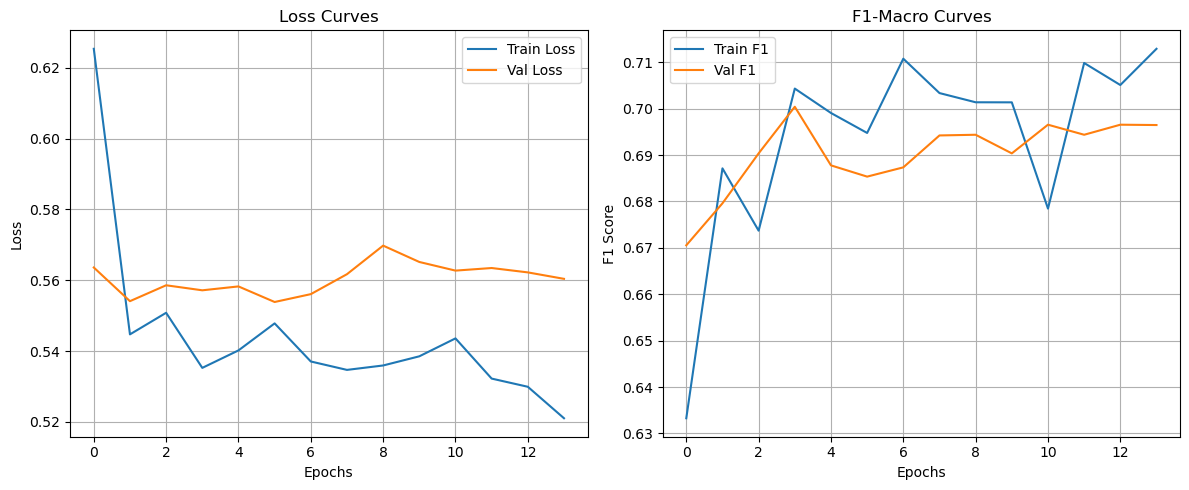

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_f1'], label='Train F1')
plt.plot(history['val_f1'], label='Val F1')
plt.title('F1-Macro Curves')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning with Optuna (MLP)

We systematically search for the best combination of hyperparameters using Bayesian Optimization (Optuna), maximizing the validation **F1-macro** score.

In [11]:
# Install Optuna if not already installed
!pip install optuna
import optuna

def objective(trial):
    # 1. Suggest hyperparameters
    batch_size = trial.suggest_categorical('batch_size', [ 8, 16, 32])
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout', 0.1, 0.6)
    
    # 2. Rebuild loaders
    trainloader_conf = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valloader_conf = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # 3. Create model, optimizer, scheduler, criterion
    model_conf = CouplingMLP(input_dim=len(coupling_cols), dropout_rate=dropout_rate).to(device)
    optimizer_conf = optim.Adam(model_conf.parameters(), lr=lr)
    scheduler_conf = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_conf, mode='min', factor=0.1, patience=3)
    criterion = nn.CrossEntropyLoss()
    
    # 4. Training loop (with Optuna pruning)
    best_val_f1 = 0.0
    for epoch in range(30):
        model_conf.train()
        for inputs, labels in trainloader_conf:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_conf.zero_grad()
            outputs = model_conf(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_conf.step()
            
        model_conf.eval()
        val_preds, val_labels = [], []
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in valloader_conf:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model_conf(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                
        epoch_val_loss = val_loss / len(valloader_conf)
        epoch_val_f1 = f1_score(val_labels, val_preds, average='macro')
        
        scheduler_conf.step(epoch_val_loss)
        
        if epoch_val_f1 > best_val_f1:
            best_val_f1 = epoch_val_f1
            
        # Report intermediate value for pruning
        trial.report(epoch_val_f1, epoch)
        
        # Handle pruning
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    return best_val_f1

In [12]:
# Run Optuna Study maximizing F1-macro score
optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, timeout=600)

print("OPTUNA STUDY COMPLETE")
print(f"Best Trial F1-Macro: {study.best_value:.4f}")
print(f"Best Parameters: {study.best_params}")

[I 2026-06-08 17:10:17,596] A new study created in memory with name: no-name-f5f02891-f6a5-47be-aade-8f8397409eb0
[I 2026-06-08 17:10:19,311] Trial 0 finished with value: 0.7071926815323042 and parameters: {'batch_size': 32, 'learning_rate': 0.00011246438274230982, 'dropout': 0.34868844338793514}. Best is trial 0 with value: 0.7071926815323042.
[I 2026-06-08 17:10:22,392] Trial 1 finished with value: 0.7164986935423665 and parameters: {'batch_size': 16, 'learning_rate': 0.000149950966409916, 'dropout': 0.20685351655342563}. Best is trial 1 with value: 0.7164986935423665.
[I 2026-06-08 17:10:25,478] Trial 2 finished with value: 0.7047619047619047 and parameters: {'batch_size': 16, 'learning_rate': 0.0001465470094293839, 'dropout': 0.5445779150550982}. Best is trial 1 with value: 0.7164986935423665.
[I 2026-06-08 17:10:27,189] Trial 3 finished with value: 0.7056037158821771 and parameters: {'batch_size': 32, 'learning_rate': 0.0033767287198430296, 'dropout': 0.18347612534431698}. Best is

OPTUNA STUDY COMPLETE
Best Trial F1-Macro: 0.7213
Best Parameters: {'batch_size': 8, 'learning_rate': 0.009700027572463079, 'dropout': 0.21825483063116005}


In [13]:
# Print study trials summary
study_df = study.trials_dataframe()
print("OPTUNA STUDY SUMMARY (SORTED BY VAL F1)")
print(study_df.sort_values(by='value', ascending=False)[['number', 'value', 'params_batch_size', 'params_learning_rate', 'params_dropout', 'state']].head(10).to_string(index=False))

OPTUNA STUDY SUMMARY (SORTED BY VAL F1)
 number    value  params_batch_size  params_learning_rate  params_dropout    state
      5 0.721318                  8              0.009700        0.218255 COMPLETE
     20 0.719397                 16              0.000257        0.257944 COMPLETE
     26 0.717106                 16              0.005809        0.220034 COMPLETE
      1 0.716499                 16              0.000150        0.206854 COMPLETE
      4 0.711383                 32              0.001585        0.137296 COMPLETE
      0 0.707193                 32              0.000112        0.348688 COMPLETE
      3 0.705604                 32              0.003377        0.183476 COMPLETE
      2 0.704762                 16              0.000147        0.544578 COMPLETE
      6 0.703943                 16              0.000431        0.115656 COMPLETE
     24 0.692113                 16              0.000206        0.168352   PRUNED


## 11. Final Model Retraining & Test Evaluation (MLP)

We retrain the model with the best parameters found during Grid Search and evaluate its final classification performance (maximizing F1-macro) on the unseen test dataset.

In [14]:
# Identify best configuration from Optuna
best_batch_size = int(study.best_params['batch_size'])
best_lr = float(study.best_params['learning_rate'])
best_dropout = float(study.best_params['dropout'])

print(f"Best Configuration: Batch Size = {best_batch_size}, LR = {best_lr}, Dropout = {best_dropout}")

# 1. Rebuild loaders with best batch size
train_loader_best = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True)
val_loader_best = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False)
test_loader_best = DataLoader(test_dataset, batch_size=best_batch_size, shuffle=False)

# 2. Re-instantiate model, optimizer, scheduler, criterion
model_best = CouplingMLP(input_dim=len(coupling_cols), dropout_rate=best_dropout).to(device)
optimizer_best = optim.Adam(model_best.parameters(), lr=best_lr)
scheduler_best = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_best, mode='min', factor=0.1, patience=3)
criterion_best = nn.CrossEntropyLoss()

# 3. Retrain model
print("\nRetraining model with best hyperparameters...")
history_best = train_model(
    model=model_best,
    train_loader=train_loader_best,
    val_loader=val_loader_best,
    criterion=criterion_best,
    optimizer=optimizer_best,
    scheduler=scheduler_best,
    device=device,
    epochs=50,
    epoch_details=True
)

# 4. Generate predictions on test set
model_best.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader_best:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_best(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 5. Compute test metrics
mlp_test_accuracy = accuracy_score(all_labels, all_preds)
mlp_test_f1 = f1_score(all_labels, all_preds, average='macro')

print(f"\nMLP Test Accuracy: {mlp_test_accuracy * 100:.2f}%")
print(f"MLP Test F1-Macro: {mlp_test_f1:.4f}")
print("\nMLP Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Best Configuration: Batch Size = 8, LR = 0.009700027572463079, Dropout = 0.21825483063116005

Retraining model with best hyperparameters...
Epoch 1/50: Train Loss: 0.6128 Acc: 67.54% F1: 0.6411 | Val Loss: 0.5931 Acc: 70.51% F1: 0.6626
SAVED model so far) (Best Val F1: 0.6626)
Epoch 2/50: Train Loss: 0.6025 Acc: 69.08% F1: 0.6452 | Val Loss: 0.5881 Acc: 64.52% F1: 0.4367
Epoch 3/50: Train Loss: 0.5731 Acc: 69.38% F1: 0.6636 | Val Loss: 0.6041 Acc: 70.51% F1: 0.6387
Epoch 4/50: Train Loss: 0.5658 Acc: 72.92% F1: 0.7067 | Val Loss: 0.5625 Acc: 72.81% F1: 0.7022
SAVED model so far) (Best Val F1: 0.7022)
Epoch 5/50: Train Loss: 0.5682 Acc: 70.92% F1: 0.6743 | Val Loss: 0.5666 Acc: 72.35% F1: 0.6860
Epoch 6/50: Train Loss: 0.5695 Acc: 71.38% F1: 0.6687 | Val Loss: 0.5574 Acc: 72.81% F1: 0.6853
Epoch 7/50: Train Loss: 0.5570 Acc: 73.08% F1: 0.6895 | Val Loss: 0.5721 Acc: 70.97% F1: 0.6314
Epoch 8/50: Train Loss: 0.5562 Acc: 70.31% F1: 0.6510 | Val Loss: 0.5558 Acc: 72.35% F1: 0.6676
Epoch 9/

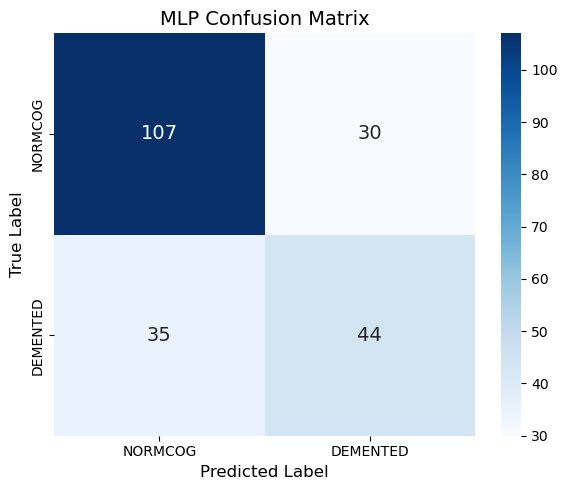

In [15]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
plt.title('MLP Confusion Matrix', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Traditional Machine Learning Comparison with 10-Fold Cross-Validation

To compare our MLP model against traditional Machine Learning algorithms, we perform a **Grid Search** with **10-Fold Cross-Validation** for both a Support Vector Machine (SVM) and a Random Forest Classifier, optimizing for the **F1-macro** score.

In [16]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 1. Define Parameter Grids
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'sigmoid']
}

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Initialize and run GridSearchCV with 10-Fold CV maximizing F1-macro
print("Running SVM Grid Search with 10-Fold CV...")
svm_grid = GridSearchCV(
    estimator=SVC(probability=True, random_state=34),
    param_grid=svm_param_grid,
    cv=10,
    scoring='f1_macro',
    n_jobs=-1
)
svm_grid.fit(X_train_coupling, y_train)
best_svm = svm_grid.best_estimator_
print(f"Best SVM Params: {svm_grid.best_params_}")
print(f"Best SVM Train CV F1-macro: {svm_grid.best_score_:.4f}\n")

print("Running Random Forest Grid Search with 10-Fold CV...")
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=34),
    param_grid=rf_param_grid,
    cv=10,
    scoring='f1_macro',
    n_jobs=-1
)
rf_grid.fit(X_train_coupling, y_train)
best_rf = rf_grid.best_estimator_
print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF Train CV F1-macro: {rf_grid.best_score_:.4f}")

Running SVM Grid Search with 10-Fold CV...
Best SVM Params: {'C': 10, 'gamma': 0.01, 'kernel': 'sigmoid'}
Best SVM Train CV F1-macro: 0.7001

Running Random Forest Grid Search with 10-Fold CV...
Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best RF Train CV F1-macro: 0.6836


In [17]:
# Predict and evaluate optimized SVM on test set
y_pred_svm = best_svm.predict(X_test_coupling)
svm_test_acc = accuracy_score(y_test, y_pred_svm)
svm_test_f1 = f1_score(y_test, y_pred_svm, average='macro')

print("--- OPTIMIZED SUPPORT VECTOR MACHINE (SVM) ---")
print(f"Test Accuracy: {svm_test_acc * 100:.2f}%")
print(f"Test F1-Macro: {svm_test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

# Predict and evaluate optimized Random Forest on test set
y_pred_rf = best_rf.predict(X_test_coupling)
rf_test_acc = accuracy_score(y_test, y_pred_rf)
rf_test_f1 = f1_score(y_test, y_pred_rf, average='macro')

print("\n--- OPTIMIZED RANDOM FOREST ---")
print(f"Test Accuracy: {rf_test_acc * 100:.2f}%")
print(f"Test F1-Macro: {rf_test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

--- OPTIMIZED SUPPORT VECTOR MACHINE (SVM) ---
Test Accuracy: 69.44%
Test F1-Macro: 0.6630

Classification Report:
              precision    recall  f1-score   support

     NORMCOG       0.74      0.79      0.77       137
    DEMENTED       0.59      0.53      0.56        79

    accuracy                           0.69       216
   macro avg       0.67      0.66      0.66       216
weighted avg       0.69      0.69      0.69       216


--- OPTIMIZED RANDOM FOREST ---
Test Accuracy: 66.67%
Test F1-Macro: 0.6388

Classification Report:
              precision    recall  f1-score   support

     NORMCOG       0.73      0.74      0.74       137
    DEMENTED       0.55      0.53      0.54        79

    accuracy                           0.67       216
   macro avg       0.64      0.64      0.64       216
weighted avg       0.66      0.67      0.67       216



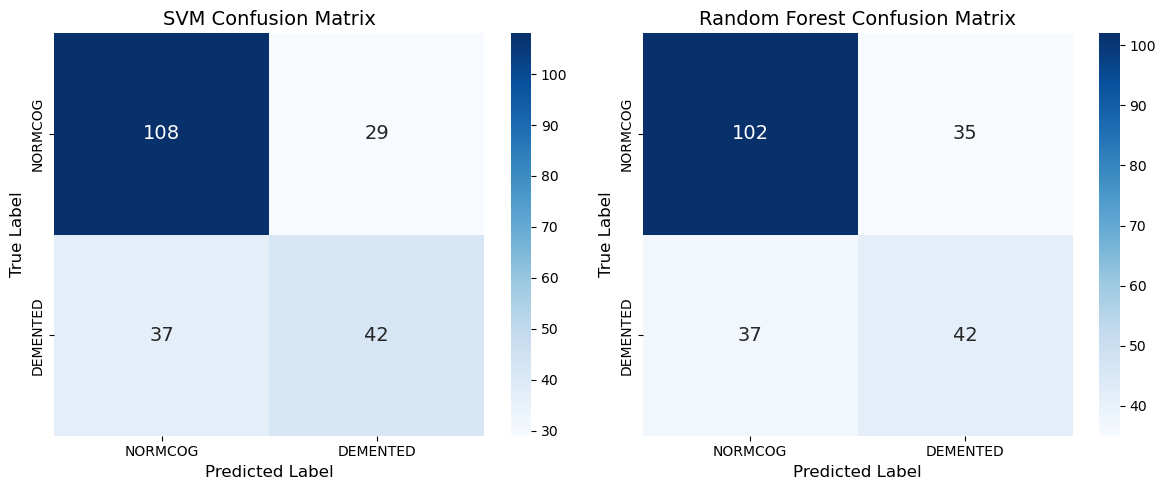

In [18]:
# Plot Confusion Matrices for SVM and Random Forest side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14}, ax=axes[0])
axes[0].set_title('SVM Confusion Matrix', fontsize=14)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14}, ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix', fontsize=14)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

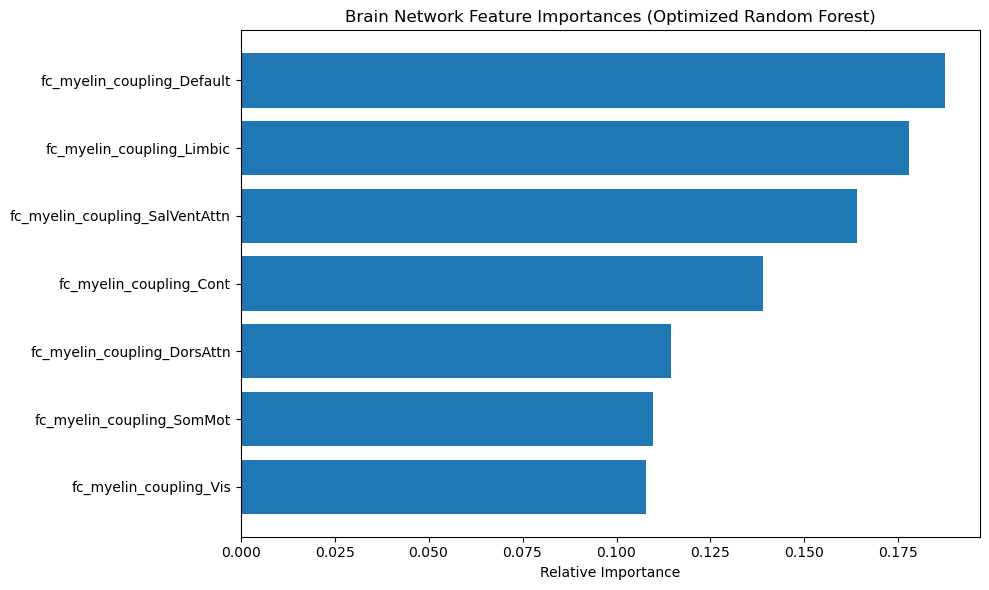

In [19]:
# Plot Feature Importances from the best Random Forest model
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the networks dynamically
num_features_to_plot = min(15, len(coupling_cols))
plt.figure(figsize=(10, 6))
plt.title("Brain Network Feature Importances (Optimized Random Forest)")
plt.barh(range(num_features_to_plot), importances[indices[:num_features_to_plot]][::-1], align="center")
plt.yticks(range(num_features_to_plot), [coupling_cols[i] for i in indices[:num_features_to_plot]][::-1])
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

In [20]:
# Overall Comparison Table
print("=== FINAL MODEL COMPARISON (TEST SET) ===")
print(f"Deep Learning MLP:       F1-Macro = {mlp_test_f1:.4f} | Accuracy = {mlp_test_accuracy * 100:.2f}%")
print(f"Support Vector Machine:  F1-Macro = {svm_test_f1:.4f} | Accuracy = {svm_test_acc * 100:.2f}%")
print(f"Random Forest:           F1-Macro = {rf_test_f1:.4f} | Accuracy = {rf_test_acc * 100:.2f}%")

=== FINAL MODEL COMPARISON (TEST SET) ===
Deep Learning MLP:       F1-Macro = 0.6711 | Accuracy = 69.91%
Support Vector Machine:  F1-Macro = 0.6630 | Accuracy = 69.44%
Random Forest:           F1-Macro = 0.6388 | Accuracy = 66.67%
